In [45]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.combine import SMOTETomek

In [46]:
data_path ="fertility.csv"

df = pd.read_csv(data_path)

df.head(8)

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal
1,spring,35,yes,no,yes,more than 3 months ago,once a week,daily,6,Altered
2,spring,27,yes,no,no,more than 3 months ago,hardly ever or never,never,9,Normal
3,spring,32,no,yes,yes,more than 3 months ago,hardly ever or never,never,7,Normal
4,spring,30,yes,yes,no,more than 3 months ago,once a week,never,9,Altered
5,spring,30,yes,no,yes,more than 3 months ago,once a week,occasional,9,Normal
6,spring,30,no,no,no,less than 3 months ago,once a week,never,8,Normal
7,spring,36,yes,yes,yes,more than 3 months ago,several times a week,never,7,Normal


In [47]:
print("Dataset Of Shape : ", df.shape)
print("Is That Null Data?", df.isnull().sum().max())

print("Unique type in data", df['Diagnosis'].unique())

Dataset Of Shape :  (100, 10)
Is That Null Data? 0
Unique type in data <StringArray>
['Normal', 'Altered']
Length: 2, dtype: str


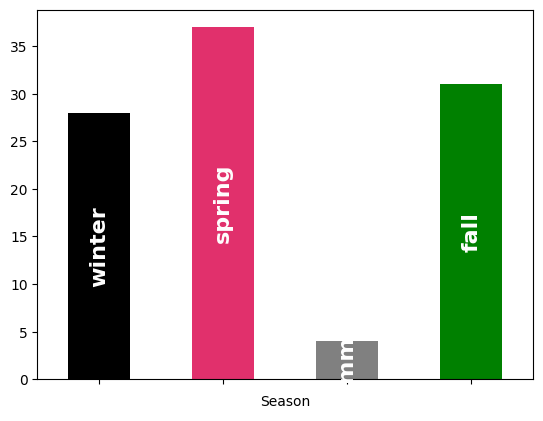

In [48]:
labels = ['winter', 'spring', 'summer', 'fall']
ax = df['Season'].value_counts().reindex(labels).plot.bar(color=['black','#E1306C','gray', 'green'])
ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', rotation=90,fontsize=16, fontweight='bold')
ax.set_xticklabels([])
plt.show()

Remapping the str data into an int64

In [49]:

d_fertility = df.copy()

d_fertility['Season'] = d_fertility['Season'].map({"spring" : 0, "fall" : 1, "winter" : 2, "summer" : 3})

d_fertility['Diagnosis'] = d_fertility['Diagnosis'].map({"Normal" : 0, "Altered" : 1})

d_fertility['Frequency of alcohol consumption'] = d_fertility['Frequency of alcohol consumption'].map({"once a week" : 0, "hardly ever or never" : 1, "several times a week" : 2, "several times a day" : 3, "every day": 4})

d_fertility['High fevers in the last year'] = d_fertility['High fevers in the last year'].map({"more than 3 months ago" : 0, "less than 3 months ago" : 1, "no" : 2})

d_fertility['Smoking habit'] = d_fertility['Smoking habit'].map({"occasional" : 0, "daily" : 1, "never" : 2,})

binary_cols = ['Childish diseases', 'Accident or serious trauma', 'Surgical intervention']

for i in binary_cols:
    d_fertility[i] = d_fertility[i].map({"yes" : 0, "no" : 1})


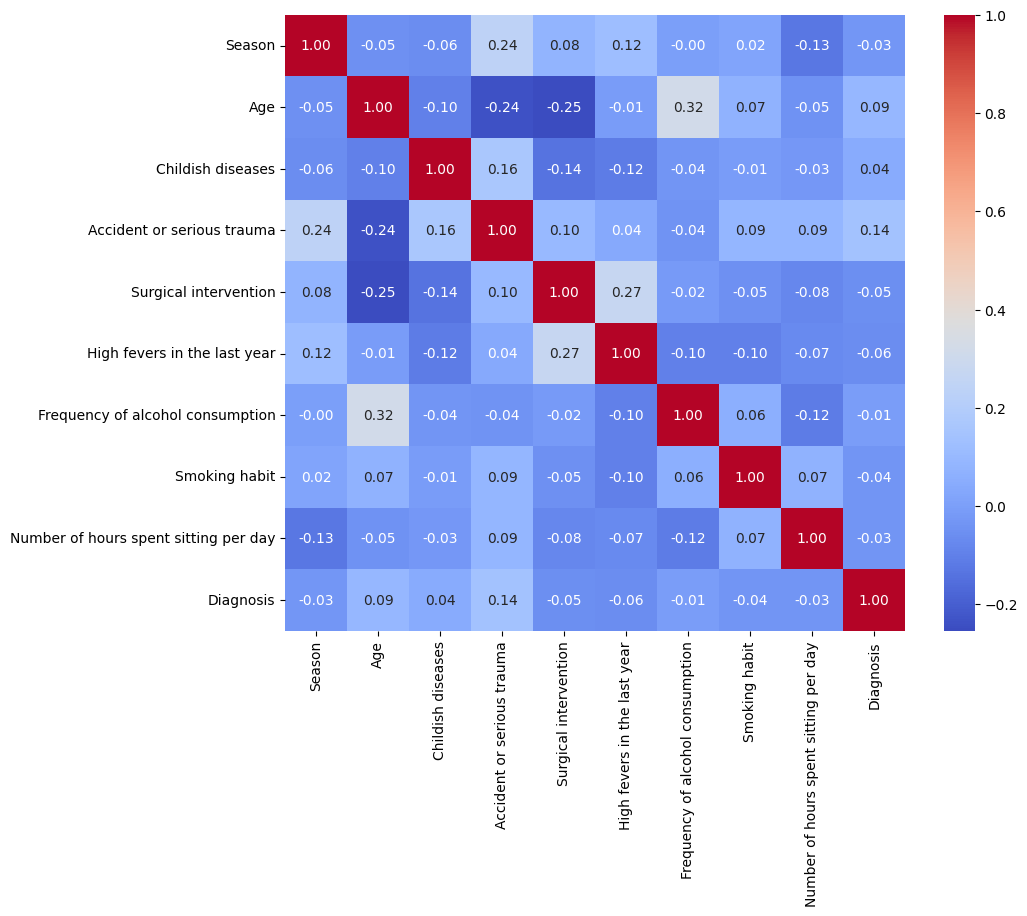

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(d_fertility.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

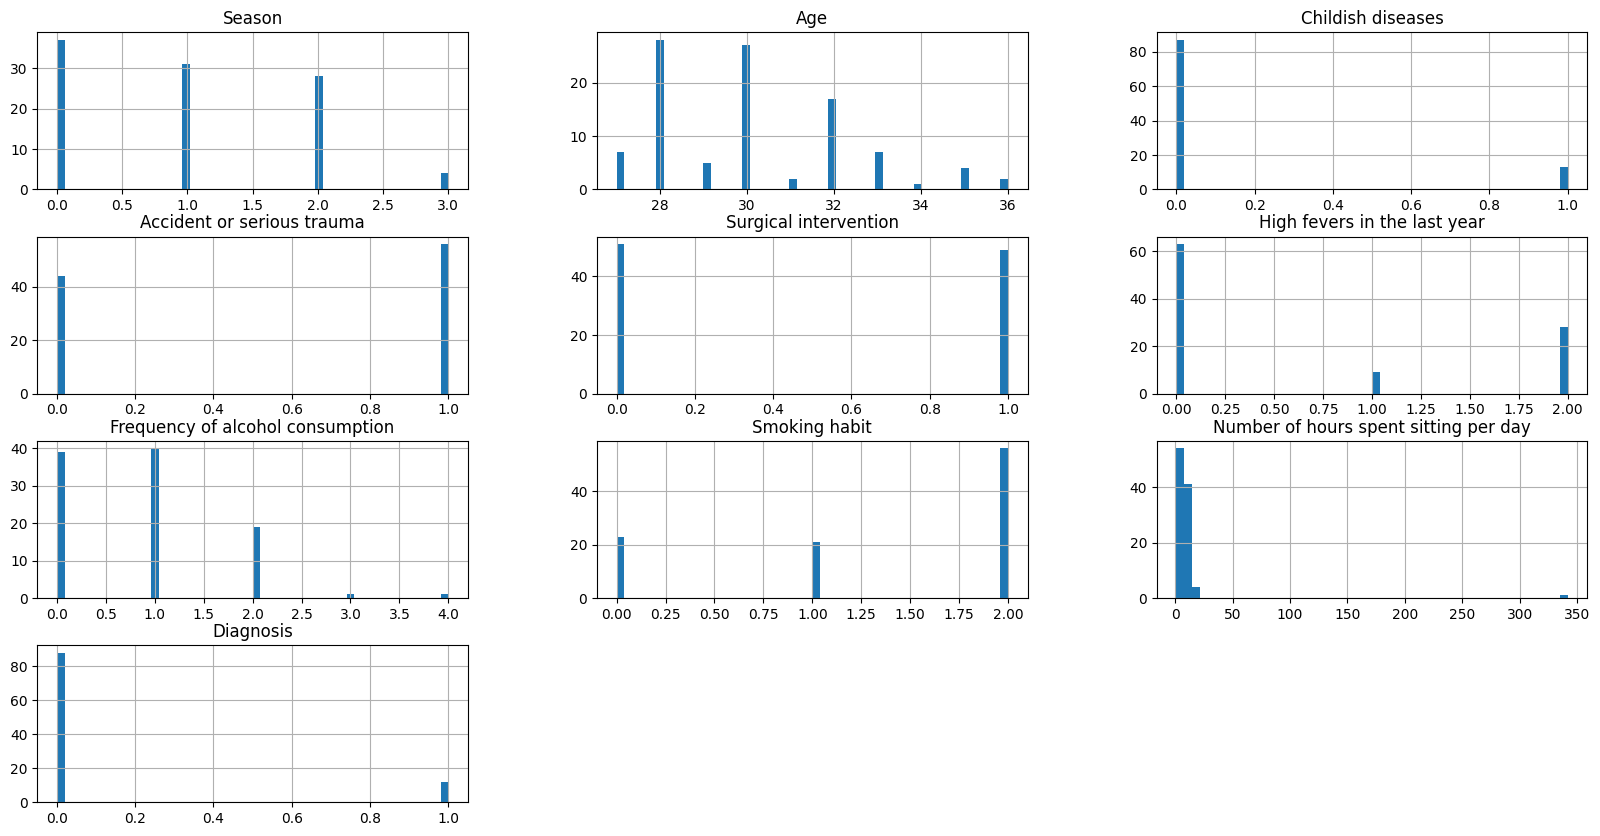

In [51]:
d_fertility.hist(bins=50, figsize=(20,10))

plt.show()

In [52]:
d_fertility.dtypes


Season                                   int64
Age                                      int64
Childish diseases                        int64
Accident or serious trauma               int64
Surgical intervention                    int64
High fevers in the last year             int64
Frequency of alcohol consumption         int64
Smoking habit                            int64
Number of hours spent sitting per day    int64
Diagnosis                                int64
dtype: object

In [53]:
print("Checking data null", d_fertility.isnull().sum().max())

Checking data null 0


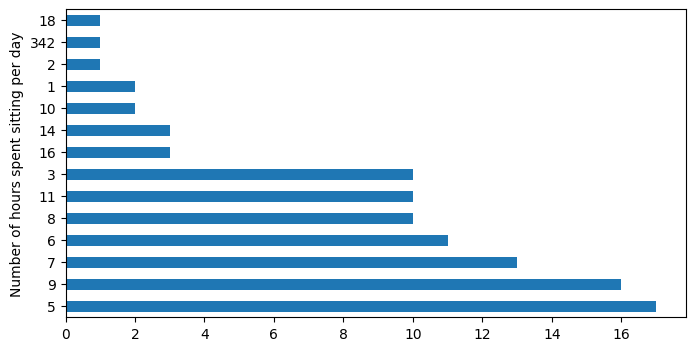

Number of hours spent sitting per day
5      17
9      16
7      13
6      11
8      10
11     10
3      10
16      3
14      3
10      2
1       2
2       1
342     1
18      1
Name: count, dtype: int64


In [54]:
plt.figure(figsize=(8, 4))

d_fertility['Number of hours spent sitting per day'].value_counts().plot.barh()

plt.show()

print(d_fertility['Number of hours spent sitting per day'].value_counts())

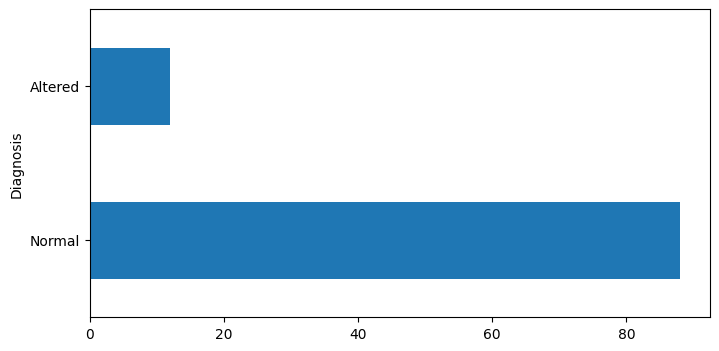

Diagnosis
0    88
1    12
Name: count, dtype: int64


In [55]:
plt.figure(figsize=(8, 4))

d_fertility['Diagnosis'].value_counts().rename(index={0 : "Normal", 1 : "Altered"}).plot.barh()

plt.show()

print(d_fertility['Diagnosis'].value_counts())

Drop the Diagnosis field cuz we dont need the type of 

In [56]:
X = d_fertility.drop(['Diagnosis'], axis=1)

y = d_fertility['Diagnosis']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2,random_state=42 )

print("X Train size", len(y_train))
print("Y Test size", len(y_valid))


print("\nLabel test count data")
print(y_valid.value_counts())
print(X_train.shape)
print("Length of data", len(y_valid))

X Train size 80
Y Test size 20

Label test count data
Diagnosis
0    18
1     2
Name: count, dtype: int64
(80, 9)
Length of data 20


In [57]:
# Balancing data using SMOTE

print(f"Data before balancing with smote {len(y_train)}")

smote = SMOTETomek(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"The Data Size After Balancing With SMOTE {len(y_train_smote)}")

Data before balancing with smote 80
The Data Size After Balancing With SMOTE 136


Train and Test Model Using DecisionTreeClassifier

Plan :
* Get the Score and Mae
* Get the predict score
* Train and test score

In [58]:
time_start = time.perf_counter()

model_dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced'
)

model_dt.fit(X_train_smote, y_train_smote)

train_predictions = model_dt.predict(X_train_smote)
test_predictions  = model_dt.predict(X_valid)

# ============================================
# EVALUATE
# ============================================
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy  = accuracy_score(y_valid, test_predictions)

print(train_accuracy)
print(test_accuracy)


0.8529411764705882
0.85


In [ ]:
# Using RandomForestClassifier

time_start = time.perf_counter()

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_rf.fit(X_train_smote, y_train_smote)

y_predict = model_dt.predict(X_valid)

print(accuracy_score(y_valid, y_predict))

0.85
